In [1]:
from pathlib import Path
import sys

# ---------------------------------------------------------------------
# Locate project root
# ---------------------------------------------------------------------

project_root = Path.cwd()

while project_root.name != "EventCameraProject":
    if project_root.parent == project_root:
        raise RuntimeError("Could not locate EventCameraProject root.")
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project Root:", project_root)

# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from src.data.evimo2.parser import EVIMO2Parser

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["axes.grid"] = False

Project Root: /home/ayon/git/EventCameraProject


In [2]:
sequence_path = Path(
    "/home/ayon/HDD/EventDatasets/EVIMO2_official/"
    "left_camera/imo/train/"
    "scene13_dyn_test_01_000000"
)

dataset = EVIMO2Parser(sequence_path)

frames = dataset.frames

print("Frames :", len(frames))
print("Objects:", len(dataset.sequence.objects))

Frames : 404
Objects: 8


In [4]:
print(f"Total frames: {len(frames)}")

print("\nFirst five frames:")

for frame in frames[:5]:
    print(
        f"id={frame.frame_id:3d}  "
        f"timestamp={frame.timestamp:.6f}  "
        f"objects={len(frame.object_states)}"
    )

Total frames: 404

First five frames:
id=  0  timestamp=0.016667  objects=8
id=  1  timestamp=0.033333  objects=8
id=  2  timestamp=0.050000  objects=8
id=  3  timestamp=0.066667  objects=8
id=  4  timestamp=0.083333  objects=8


In [5]:
frame_index = 0

frame = frames[frame_index]

print(f"Frame ID      : {frame.frame_id}")
print(f"Timestamp     : {frame.timestamp:.6f}")
print(f"Objects       : {len(frame.object_states)}")

print("\nVisible objects")

for obj in frame.object_states:
    print(obj.object_id)

Frame ID      : 0
Timestamp     : 0.016667
Objects       : 8

Visible objects
11
14
15
22
23
24
5
6


In [6]:
frame_id = frame.frame_id

try:
    depth = dataset.load_depth(frame_id)
    print("Depth loaded:", depth.shape)
except KeyError:
    depth = None
    print("Depth unavailable")

try:
    mask = dataset.load_mask(frame_id)
    print("Mask loaded :", mask.shape)
except KeyError:
    mask = None
    print("Mask unavailable")

Depth loaded: (480, 640)
Mask loaded : (480, 640)


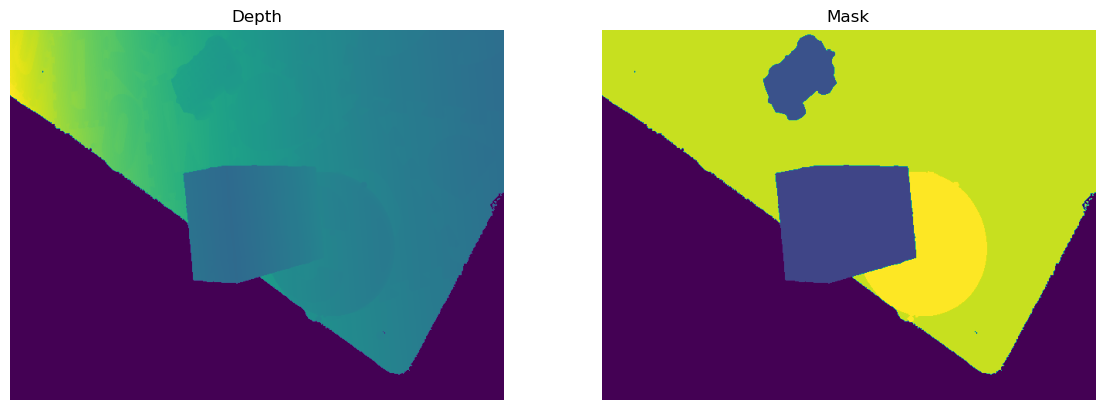

In [7]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

if depth is not None:
    axes[0].imshow(depth)
    axes[0].set_title("Depth")
else:
    axes[0].text(
        0.5,
        0.5,
        "No depth",
        ha="center",
        va="center",
        fontsize=16,
    )

if mask is not None:
    axes[1].imshow(mask)
    axes[1].set_title("Mask")
else:
    axes[1].text(
        0.5,
        0.5,
        "No mask",
        ha="center",
        va="center",
        fontsize=16,
    )

for ax in axes:
    ax.axis("off")

plt.show()

In [8]:
from ipywidgets import interact, IntSlider

def show_frame(frame_index):

    frame = frames[frame_index]

    try:
        depth = dataset.load_depth(frame.frame_id)
    except KeyError:
        depth = None

    try:
        mask = dataset.load_mask(frame.frame_id)
    except KeyError:
        mask = None

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14,6)
    )

    if depth is not None:
        axes[0].imshow(depth)
        axes[0].set_title("Depth")
    else:
        axes[0].text(
            0.5,
            0.5,
            "No depth",
            ha="center",
            va="center",
            fontsize=16,
        )

    if mask is not None:
        axes[1].imshow(mask)
        axes[1].set_title("Mask")
    else:
        axes[1].text(
            0.5,
            0.5,
            "No mask",
            ha="center",
            va="center",
            fontsize=16,
        )

    for ax in axes:
        ax.axis("off")

    plt.suptitle(
        f"Frame {frame.frame_id}    "
        f"Timestamp {frame.timestamp:.6f}s\n"
        f"Objects: {[obj.object_id for obj in frame.object_states]}"
    )

    plt.show()


interact(
    show_frame,
    frame_index=IntSlider(
        value=0,
        min=0,
        max=len(frames)-1,
        step=1,
        continuous_update=False,
    ),
);

interactive(children=(IntSlider(value=0, continuous_update=False, description='frame_index', max=403), Output(…

In [11]:
from src.preprocessing.object_motion import collect_world_trajectories

object_trajs = collect_world_trajectories(
    dataset.frames,
    dataset.objects,
)

print(f"Number of trajectories: {len(object_trajs)}\n")

for object_id, traj in object_trajs.items():
    print(f"Object {object_id:2d}: {len(traj.positions)} poses")

Number of trajectories: 8

Object 11: 392 poses
Object 14: 392 poses
Object 15: 392 poses
Object 22: 392 poses
Object 23: 392 poses
Object 24: 392 poses
Object  5: 392 poses
Object  6: 392 poses


In [12]:
camera_positions = []
camera_timestamps = []

for frame in dataset.frames:

    if frame.camera_pose is None:
        continue

    camera_positions.append(
        frame.camera_pose.translation
    )

    camera_timestamps.append(
        frame.timestamp
    )

camera_positions = np.asarray(camera_positions)
camera_timestamps = np.asarray(camera_timestamps)

print(camera_positions.shape)

(392, 3)


In [13]:
def trajectory_until(times, positions, timestamp):
    """
    Return trajectory up to a given timestamp.
    """

    idx = np.searchsorted(
        times,
        timestamp,
        side="right",
    )

    return positions[:idx]


def current_position(times, positions, timestamp):
    """
    Return latest position at or before timestamp.
    """

    idx = np.searchsorted(
        times,
        timestamp,
        side="right",
    )

    idx = max(0, idx - 1)

    return positions[idx]

In [15]:
for frame in dataset.frames[:10]:
    print(
        frame.frame_id,
        frame.timestamp,
    )

0 0.016667
1 0.033333
2 0.05
3 0.066667
4 0.083333
5 0.1
6 0.116667
7 0.133333
8 0.15
9 0.166667


In [16]:
available_frames = []

for frame in dataset.frames:

    try:
        depth = dataset.load_depth(frame.frame_id)

        available_frames.append(frame.frame_id)

    except KeyError:
        continue

print(len(available_frames))

print(available_frames[:20])

404
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [31]:
from ipywidgets import interact, IntSlider
import numpy as np
import matplotlib.pyplot as plt
# -------------------------------------------------------
# Event accumulation parameters
# -------------------------------------------------------

EVENT_WINDOW_MS = 10.0

event_dt = EVENT_WINDOW_MS / 1000.0

def show_frame(frame_index):

    frame = frames[frame_index]

    # --------------------------------------------------
    # Depth
    # --------------------------------------------------

    try:
        depth = dataset.load_depth(frame.frame_id)
    except KeyError:
        depth = None

    # --------------------------------------------------
    # Mask
    # --------------------------------------------------

    try:
        mask = dataset.load_mask(frame.frame_id)
    except KeyError:
        mask = None

    # --------------------------------------------------
    # RGB (placeholder until flea3_7 parser is added)
    # --------------------------------------------------

    rgb = None

    # --------------------------------------------------
    # Event Image
    # --------------------------------------------------

    # --------------------------------------------------
# Event Image
# --------------------------------------------------

    xy, t, p = dataset.get_events(
        frame.timestamp,
        frame.timestamp + event_dt,
    )

    event_image = np.zeros(
        (
            dataset.sequence.camera.height,
            dataset.sequence.camera.width,
        ),
        dtype=np.int16,
    )

    if len(t) > 0:

        x = xy[:, 0].astype(np.int32)
        y = xy[:, 1].astype(np.int32)

        # EVIMO stores polarity as 0/1
        polarity = np.where(p > 0, 1, -1)

        np.add.at(
            event_image,
            (y, x),
            polarity,
        )

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 10),
    )

    # --------------------------------------------------
    # RGB
    # --------------------------------------------------

    if rgb is None:

        axes[0,0].text(
            0.5,
            0.5,
            "RGB not implemented\n(flea3_7)",
            ha="center",
            va="center",
            fontsize=16,
        )

    else:

        axes[0,0].imshow(rgb)

    axes[0,0].set_title("RGB")

    # --------------------------------------------------
    # Event Image
    # --------------------------------------------------

    vmax = np.max(np.abs(event_image))

    if vmax == 0:
        vmax = 1

    axes[0,1].imshow(
        event_image,
        cmap="bwr",
        vmin=-vmax,
        vmax=vmax,
    )

    axes[0,1].set_title(
        f"Events ({EVENT_WINDOW_MS:.0f} ms)"
    )

    # --------------------------------------------------
    # Depth
    # --------------------------------------------------

    if depth is not None:

        axes[1,0].imshow(depth)

    else:

        axes[1,0].text(
            0.5,
            0.5,
            "No depth",
            ha="center",
            va="center",
            fontsize=16,
        )

    axes[1,0].set_title("Depth")

    # --------------------------------------------------
    # Mask
    # --------------------------------------------------

    if mask is not None:

        axes[1,1].imshow(mask)

    else:

        axes[1,1].text(
            0.5,
            0.5,
            "No mask",
            ha="center",
            va="center",
            fontsize=16,
        )

    axes[1,1].set_title("Mask")

    # --------------------------------------------------
    # Cosmetics
    # --------------------------------------------------

    for ax in axes.flat:
        ax.axis("off")

    plt.suptitle(
        f"Frame {frame.frame_id}    "
        f"Timestamp {frame.timestamp:.6f}s\n"
        f"Objects: {[obj.object_id for obj in frame.object_states]}"
    )

    plt.tight_layout()

    plt.show()


interact(
    show_frame,
    frame_index=IntSlider(
        value=0,
        min=0,
        max=len(frames)-1,
        step=1,
        continuous_update=False,
    ),
);

interactive(children=(IntSlider(value=0, continuous_update=False, description='frame_index', max=403), Output(…

In [ ]:
import ipywidgets as widgets
from IPython.display import display

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(frames)-1,
    step=1,
    description="Frame",
    continuous_update=False,
    readout=True,
    layout=widgets.Layout(width="700px"),
    style={"description_width": "70px"},
)

play = widgets.Play(
    value=0,
    min=0,
    max=len(frames)-1,
    step=1,
    interval=40,      # milliseconds
)

widgets.jslink(
    (play, "value"),
    (slider, "value"),
)

prev_button = widgets.Button(
    description="◀ Prev",
    button_style="info",
)

next_button = widgets.Button(
    description="Next ▶",
    button_style="info",
)

jump_back = widgets.Button(
    description="-10",
)

jump_forward = widgets.Button(
    description="+10",
)

In [35]:
output = widgets.Output()
def refresh(change=None):

    with output:

        output.clear_output(wait=True)

        show_frame(slider.value)


slider.observe(refresh, names="value")

def previous(_):

    slider.value = max(
        slider.min,
        slider.value - 1,
    )


def next(_):

    slider.value = min(
        slider.max,
        slider.value + 1,
    )


def minus10(_):

    slider.value = max(
        slider.min,
        slider.value - 10,
    )


def plus10(_):

    slider.value = min(
        slider.max,
        slider.value + 10,
    )


prev_button.on_click(previous)
next_button.on_click(next)
jump_back.on_click(minus10)
jump_forward.on_click(plus10)

controls = widgets.HBox(
    [
        play,
        prev_button,
        next_button,
        jump_back,
        jump_forward,
        slider,
    ]
)

display(controls)

display(output)

refresh()

Output()

In [43]:
from pathlib import Path

import cv2
import numpy as np
from tqdm.notebook import tqdm


# ==========================================================
# Configuration
# ==========================================================

EVENT_WINDOW_MS = 10.0

event_dt = EVENT_WINDOW_MS / 1000.0

sequence_dir = Path(dataset.sequence_dir)

# corresponding RGB sequence
rgb_sequence_dir = Path(
    str(sequence_dir).replace(
        "/left_camera/",
        "/flea3_7/",
    )
)

rgb_archive = np.load(
    rgb_sequence_dir / "dataset_classical.npz",
    allow_pickle=False,
)

output_file = "evimo2_visualization.mp4"

FPS = 30


# ==========================================================
# Video writer
# ==========================================================

frame_h = dataset.sequence.camera.height
frame_w = dataset.sequence.camera.width

canvas_h = frame_h * 2
canvas_w = frame_w * 2

writer = cv2.VideoWriter(
    output_file,
    cv2.VideoWriter_fourcc(*"mp4v"),
    FPS,
    (canvas_w, canvas_h),
)

print(f"Writing video to {output_file}")


# ==========================================================
# Render every frame
# ==========================================================

for frame in tqdm(frames):

    ########################################################
# RGB
########################################################

    rgb_key = f"classical_{frame.frame_id:010d}"

    if rgb_key in rgb_archive.files:

        rgb = rgb_archive[rgb_key]

        # Convert grayscale to BGR if necessary
        if rgb.ndim == 2:
            rgb = cv2.cvtColor(
                rgb,
                cv2.COLOR_GRAY2BGR,
            )

        # Convert RGB -> BGR if needed (OpenCV writes BGR)
        if rgb.shape[2] == 3:
            rgb = cv2.cvtColor(
                rgb,
                cv2.COLOR_RGB2BGR,
            )

        # Resize to event-camera resolution
        rgb = cv2.resize(
            rgb,
            (frame_w, frame_h),
            interpolation=cv2.INTER_AREA,
        )

    else:

        rgb = np.zeros(
            (
                frame_h,
                frame_w,
                3,
            ),
            dtype=np.uint8,
        )

        cv2.putText(
            rgb,
            "RGB unavailable",
            (40,60),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255,255,255),
            2,
        )

    ########################################################
    # Depth
    ########################################################

    depth = dataset.load_depth(frame.frame_id)

    if depth is None:

        depth_vis = np.zeros(
            (frame_h, frame_w, 3),
            dtype=np.uint8,
        )

        cv2.putText(
            depth_vis,
            "No Depth",
            (40, 60),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255,255,255),
            2,
        )

    else:

        depth_vis = cv2.normalize(
            depth,
            None,
            0,
            255,
            cv2.NORM_MINMAX,
        )

        depth_vis = depth_vis.astype(np.uint8)

        depth_vis = cv2.applyColorMap(
            depth_vis,
            cv2.COLORMAP_TURBO,
        )

    ########################################################
    # Mask
        ########################################################

    ########################################################
    # Mask
    ########################################################
    dynamic_objects = {
        5,
        15,
        24,
    }
    mask = dataset.load_mask(frame.frame_id)

    if mask is None:

        mask_vis = np.zeros(
            (frame_h, frame_w, 3),
            dtype=np.uint8,
        )

        cv2.putText(
            mask_vis,
            "No Mask",
            (40, 60),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255,255,255),
            2,
        )

    else:

        # --------------------------------------------------
        # Object IDs
        # --------------------------------------------------

        ids = (mask // 1000).astype(np.int32)

        mask_vis = np.zeros(
            (frame_h, frame_w, 3),
            dtype=np.uint8,
        )

        # --------------------------------------------------
        # Colors
        # --------------------------------------------------

        background_color = (30, 30, 30)

        static_color = (0, 180, 0)       # Green
        dynamic_color = (0, 0, 255)      # Red (OpenCV BGR)

        mask_vis[:] = background_color

        # --------------------------------------------------
        # Paint every object
        # --------------------------------------------------

        for obj_id in np.unique(ids):

            if obj_id == 0:
                continue

            if obj_id in dynamic_objects:

                color = dynamic_color

            else:

                color = static_color

            mask_vis[ids == obj_id] = color

            # ----------------------------------------------
            # Draw object ID at centroid
            # ----------------------------------------------

            ys, xs = np.where(ids == obj_id)

            if len(xs):

                cx = int(xs.mean())
                cy = int(ys.mean())

                cv2.putText(
                    mask_vis,
                    str(obj_id),
                    (cx, cy),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255,255,255),
                    1,
                    cv2.LINE_AA,
                )
    ########################################################
    # Events
    ########################################################

    xy, t, p = dataset.get_events(
        frame.timestamp,
        frame.timestamp + event_dt,
    )

    event = np.zeros(
        (
            frame_h,
            frame_w,
        ),
        dtype=np.int16,
    )

    if len(t):

        polarity = np.where(
            p > 0,
            1,
            -1,
        )

        np.add.at(
            event,
            (
                xy[:,1].astype(np.int32),
                xy[:,0].astype(np.int32),
            ),
            polarity,
        )

    vmax = max(
        1,
        np.max(np.abs(event)),
    )

    positive = np.clip(event,0,vmax)
    negative = np.clip(-event,0,vmax)

    event_rgb = np.zeros(
        (
            frame_h,
            frame_w,
            3,
        ),
        dtype=np.uint8,
    )

    event_rgb[:,:,2] = (
        positive * 255 / vmax
    ).astype(np.uint8)

    event_rgb[:,:,0] = (
        negative * 255 / vmax
    ).astype(np.uint8)

    ########################################################
    # Labels
    ########################################################

    def label(img,text):

        cv2.putText(
            img,
            text,
            (15,35),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255,255,255),
            2,
            cv2.LINE_AA,
        )

    label(rgb,"RGB")
    label(event_rgb,f"Events ({EVENT_WINDOW_MS:.0f} ms)")
    label(depth_vis,"Depth")
    label(mask_vis,"Mask")

    ########################################################
    # Compose
    ########################################################

    top = np.hstack(
        (
            rgb,
            event_rgb,
        )
    )

    bottom = np.hstack(
        (
            depth_vis,
            mask_vis,
        )
    )

    canvas = np.vstack(
        (
            top,
            bottom,
        )
    )

    ########################################################
    # Timestamp
    ########################################################

    cv2.putText(
        canvas,
        f"Frame {frame.frame_id}   Time {frame.timestamp:.6f}s",
        (20,canvas_h-20),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255,255,255),
        2,
        cv2.LINE_AA,
    )

    writer.write(canvas)


writer.release()
dynamic_objects = {
    5,
    15,
    24,
}
print()
print("Finished.")
print(output_file)

Writing video to evimo2_visualization.mp4


  0%|          | 0/404 [00:00<?, ?it/s]


Finished.
evimo2_visualization.mp4


In [37]:
print("RGB sample shape :", rgb_archive[rgb_archive.files[0]].shape)
print("Event resolution :", frame_w, frame_h)

RGB sample shape : (1552, 2080, 3)
Event resolution : 640 480
